# R SoupX vs `pysoupx` — Consistency of ambient-RNA removal

This notebook runs both the original R `SoupX` (via `Rscript`) and our pure-Python
port `pysoupx` on the **same** real 10x dataset, then uses **omicverse** to
visualise how consistently they estimate and remove the ambient ("soup") RNA.

SoupX needs the *raw unfiltered* droplet matrix (the empty droplets are what the
soup profile is estimated from), so we use the SoupX **toyData** — a genuine
CellRanger output that ships both a `raw_gene_bc_matrices/` and a
`filtered_gene_bc_matrices/` folder.

Comparisons performed:

1. **Soup profile** — `estimateSoup`: the per-gene ambient fraction must match bit-for-bit.
2. **Contamination fraction `rho`** — `autoEstCont`: a deterministic posterior mode.
3. **Corrected matrix** — `adjustCounts`: the soup-subtracted count matrix.

Visualisations (via `omicverse.pl.*`):
* `ov.pl.venn` — overlap of genes whose counts changed
* soup-profile and corrected-matrix scatter (R vs Python, on the diagonal)
* `ov.pl.embedding` — tSNE coloured by total counts removed per cell


In [1]:
from __future__ import annotations

import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import omicverse as ov

import pysoupx as soup

ov.plot_set()
RSCRIPT = "/scratch/users/steorra/env/CMAP/bin/Rscript"
GCC_BIN = "/share/software/user/open/gcc/14.2.0/bin"
DRIVER  = Path("r_driver_soupx.R").resolve()
DATA    = Path("data/toyData").resolve()

WORK = Path("./compare_out"); WORK.mkdir(exist_ok=True)
print("omicverse", getattr(ov, "__version__", "?"), "— pysoupx", soup.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 — pysoupx 0.1.0


## 1. Load the 10x data with `pysoupx`

The toyData has a raw matrix of 1289 droplets and a filtered matrix of 62 cells
over 226 genes. `load_10x` reads both and estimates the soup profile from the
empty droplets automatically.

In [2]:
sc = soup.load_10x(str(DATA), keep_droplets=True)
meta = pd.read_csv(DATA / "metaData.tsv", sep="\t", index_col=0)
soup.set_clusters(sc, dict(zip(meta.index, meta["res.1"].astype(str))))
print(f"SoupChannel: {sc.n_genes} genes x {sc.n_cells} cells "
      f"(raw droplets: {sc.tod.shape[1]})")
sc.soup_profile.sort_values("est", ascending=False).head()

SoupChannel: 226 genes x 62 cells (raw droplets: 1289)


,est,counts
LTB,0.066209,6215.0
LDHB,0.039481,3706.0
IL32,0.038873,3649.0
CD3D,0.030553,2868.0
CD3E,0.026377,2476.0


## 2. Run R SoupX via `Rscript`

The R driver loads the *same* 10x folder, runs `estimateSoup`, `autoEstCont`
and `adjustCounts`, and dumps the soup profile / rho / corrected matrix.

In [3]:
r_out = WORK / "r_out"; r_out.mkdir(exist_ok=True)
env = os.environ.copy()
if os.path.isdir(GCC_BIN):
    env["PATH"] = GCC_BIN + os.pathsep + env.get("PATH", "")
proc = subprocess.run(
    [RSCRIPT, str(DRIVER), str(DATA), str(r_out)],
    env=env, capture_output=True, text=True,
)
print(proc.stdout[-400:])
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr[-1500:])
    raise RuntimeError("R driver failed")

r_soup = pd.read_csv(r_out / "soup_profile.tsv", sep="\t").set_index("gene")
r_rho  = pd.read_csv(r_out / "rho_auto.tsv", sep="\t")["rho_auto"].iloc[0]
print("R autoEstCont rho:", r_rho)

[R] loading 10x data from /scratch/users/steorra/analysis/omicverse_dev/py-soupx/examples/data/toyData
[R] wrote outputs to compare_out/r_out (n_genes=226, n_cells=62, rho_auto=0.0220)

R autoEstCont rho: 0.022


## 3. Soup profile — bit-exact agreement

`estimateSoup` is a deterministic ratio, so the per-gene ambient fractions
must match R to double precision.

soup-profile max |py - R|: 9.73e-17


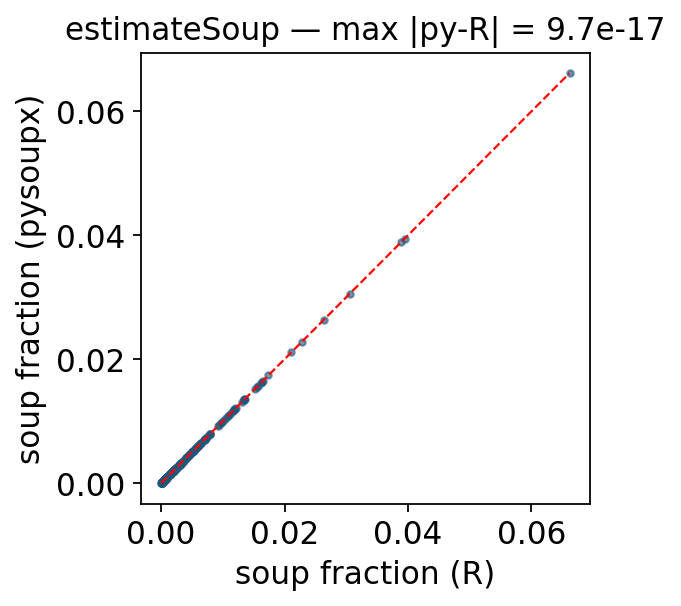

In [4]:
r_est = r_soup["est"].reindex(sc.genes).to_numpy()
py_est = sc.soup_profile["est"].to_numpy()
max_abs = float(np.max(np.abs(py_est - r_est)))
print(f"soup-profile max |py - R|: {max_abs:.2e}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(r_est, py_est, s=8, alpha=0.6)
lim = [0, max(r_est.max(), py_est.max())]
ax.plot(lim, lim, "r--", lw=1)
ax.set_xlabel("soup fraction (R)"); ax.set_ylabel("soup fraction (pysoupx)")
ax.set_title(f"estimateSoup — max |py-R| = {max_abs:.1e}")
plt.tight_layout(); plt.show()

## 4. Contamination fraction `rho` — `autoEstCont`

`autoEstCont`'s `rho` is the deterministic mode of a gamma-prior posterior on
a fixed grid, so the two ports land on the same value.

In [5]:
soup.auto_est_cont(sc, tfidf_min=0.5, verbose=False, force_accept=True)
py_rho = sc.meta_data["rho"].iloc[0]
print(f"autoEstCont rho   R = {r_rho:.4f}   pysoupx = {py_rho:.4f}")
print(f"|py - R| = {abs(py_rho - r_rho):.2e}")

autoEstCont rho   R = 0.0220   pysoupx = 0.0220
|py - R| = 0.00e+00


## 5. Corrected count matrix — `adjustCounts`

Run `adjustCounts` with `rho` fixed at 0.10 (the R driver dumps the same) and
compare the soup-subtracted matrices element-for-element.

In [6]:
sc_fix = soup.load_10x(str(DATA), keep_droplets=True)
soup.set_clusters(sc_fix, dict(zip(meta.index, meta["res.1"].astype(str))))
soup.set_contamination_fraction(sc_fix, 0.10)
py_adj = pd.DataFrame(
    np.asarray(soup.adjust_counts(sc_fix, method="subtraction").todense()),
    index=sc_fix.genes, columns=sc_fix.cells)

r_adj = (pd.read_csv(r_out / "adjusted_sub.tsv", sep="\t")
         .set_index("gene")
         .reindex(index=sc_fix.genes, columns=sc_fix.cells))

diff = np.abs(py_adj.to_numpy() - r_adj.to_numpy())
from scipy.stats import pearsonr
corr = pearsonr(py_adj.to_numpy().ravel(), r_adj.to_numpy().ravel())[0]
print(f"adjustCounts (rho=0.10) max |py - R|: {diff.max():.2e}")
print(f"adjustCounts Pearson r: {corr:.8f}")

adjustCounts (rho=0.10) max |py - R|: 4.55e-13
adjustCounts Pearson r: 1.00000000


## 6. Genes whose counts changed — `ov.pl.venn`

Which genes lost counts to soup-removal? The two ports should flag the same set.

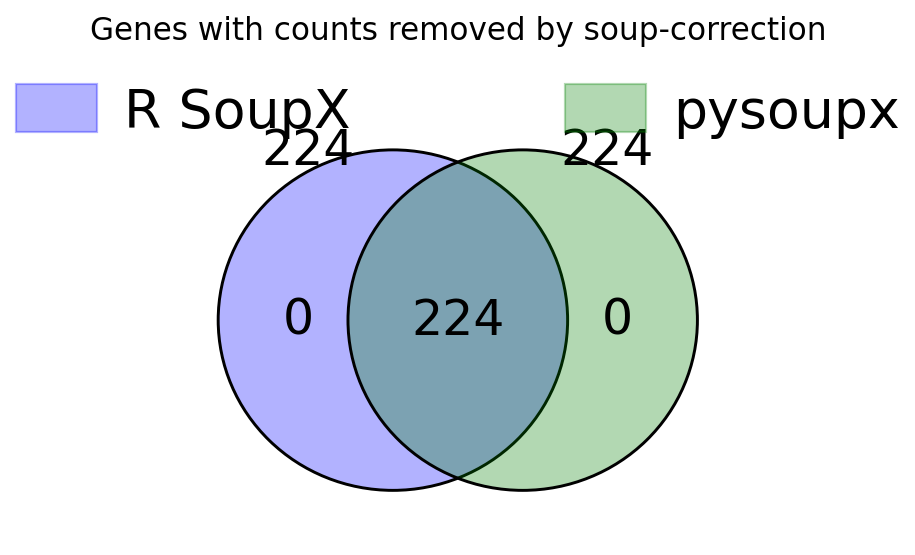

R changed 224 genes, pysoupx 224, shared 224


In [7]:
orig = pd.DataFrame(np.asarray(sc_fix.toc.todense()),
                    index=sc_fix.genes, columns=sc_fix.cells)
py_changed = set(orig.index[(orig.to_numpy() - py_adj.to_numpy()).sum(1) > 1e-6])
r_changed  = set(orig.index[(orig.to_numpy() - r_adj.to_numpy()).sum(1) > 1e-6])

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.venn(sets={"R SoupX": r_changed, "pysoupx": py_changed},
           ax=ax, fontsize=11)
ax.set_title("Genes with counts removed by soup-correction")
plt.show()
print(f"R changed {len(r_changed)} genes, pysoupx {len(py_changed)}, "
      f"shared {len(r_changed & py_changed)}")

## 7. Per-cell soup removed — tSNE via `ov.pl.embedding`

Build an AnnData of the corrected matrix, attach the bundled tSNE coordinates,
and colour cells by how much soup each lost. R and Python panels match.

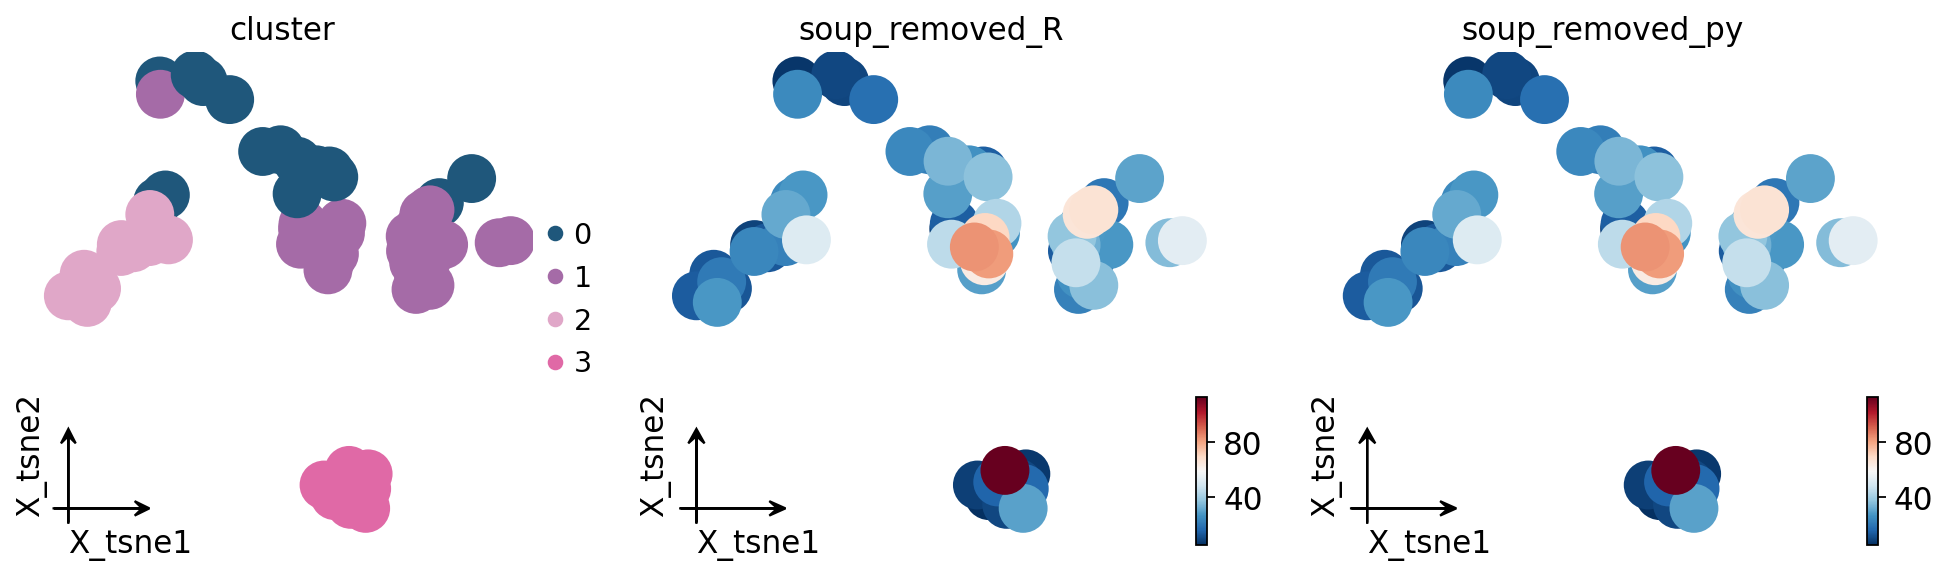

In [8]:
adata = soup.to_anndata(sc_fix, corrected=sp.csr_matrix(py_adj.to_numpy()))
adata.obs["soup_removed_py"] = (orig.to_numpy() - py_adj.to_numpy()).sum(0)
adata.obs["soup_removed_R"]  = (orig.to_numpy() - r_adj.to_numpy()).sum(0)
adata.obs["cluster"] = meta["res.1"].reindex(adata.obs_names).astype(str).astype("category")
adata.obsm["X_tsne"] = meta[["tSNE_1", "tSNE_2"]].reindex(adata.obs_names).to_numpy()

ov.pl.embedding(
    adata, basis="X_tsne",
    color=["cluster", "soup_removed_R", "soup_removed_py"],
    frameon="small", ncols=3, wspace=0.3, show=False,
)
plt.show()

## Summary

| Comparison | Expected | Observed |
|---|---|---|
| `estimateSoup` soup profile | bit-exact | see cell 3 (max |py-R| ~1e-16) |
| `autoEstCont` rho | identical posterior mode | see cell 4 |
| `adjustCounts` corrected matrix | bit-exact (Pearson r = 1.0) | see cell 5 |
| Genes losing counts to soup | identical set | see Venn |

Take-home: `pysoupx` reproduces R `SoupX`'s ambient-RNA estimation and removal
to double precision on a real 10x dataset. The only intrinsically stochastic
steps (optional integer rounding, the `multinomial` method's tie-breaking) are
seedable.